In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
import util
import util_with_inter
import jax
from jax import numpy as jnp
from importlib import reload

jax.config.update("jax_enable_x64", True)

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [3]:
tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_200pc_noparallaxovererror.vot")

In [4]:
def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

In [5]:
# Distance
deg2rad = np.pi/180.
dist_pc = r_from_plx(tab["parallax"])
# Absolute magnitude
apparent_magnitude = np.array(tab["phot_g_mean_mag"])
absolute_magnitude = apparent_magnitude - 5.*np.log10(dist_pc) + 5

parallax_over_error = np.array(tab["parallax"]/tab["parallax_error"])
min = 5
mask0 = parallax_over_error > min
group1 = (absolute_magnitude[~mask0] >= 5) & (absolute_magnitude[~mask0] < 6)
group2 = (absolute_magnitude[~mask0] >= 6) & (absolute_magnitude[~mask0] < 7)
group3 = (absolute_magnitude[~mask0] >= 7) & (absolute_magnitude[~mask0] <= 8)

print("Requirement: parallax/standarterror(parallax) is larger than {}. This ensures useful parallax measurment. Removes an additional {:.2e} sources".format(min, np.nansum(~mask0)))
print("We are left with {:.2e} sources".format(np.nansum(mask0)))

Requirement: parallax/standarterror(parallax) is larger than 5. This ensures useful parallax measurment. Removes an additional 1.17e+04 sources
We are left with 6.33e+05 sources


#### Selecting a subsample

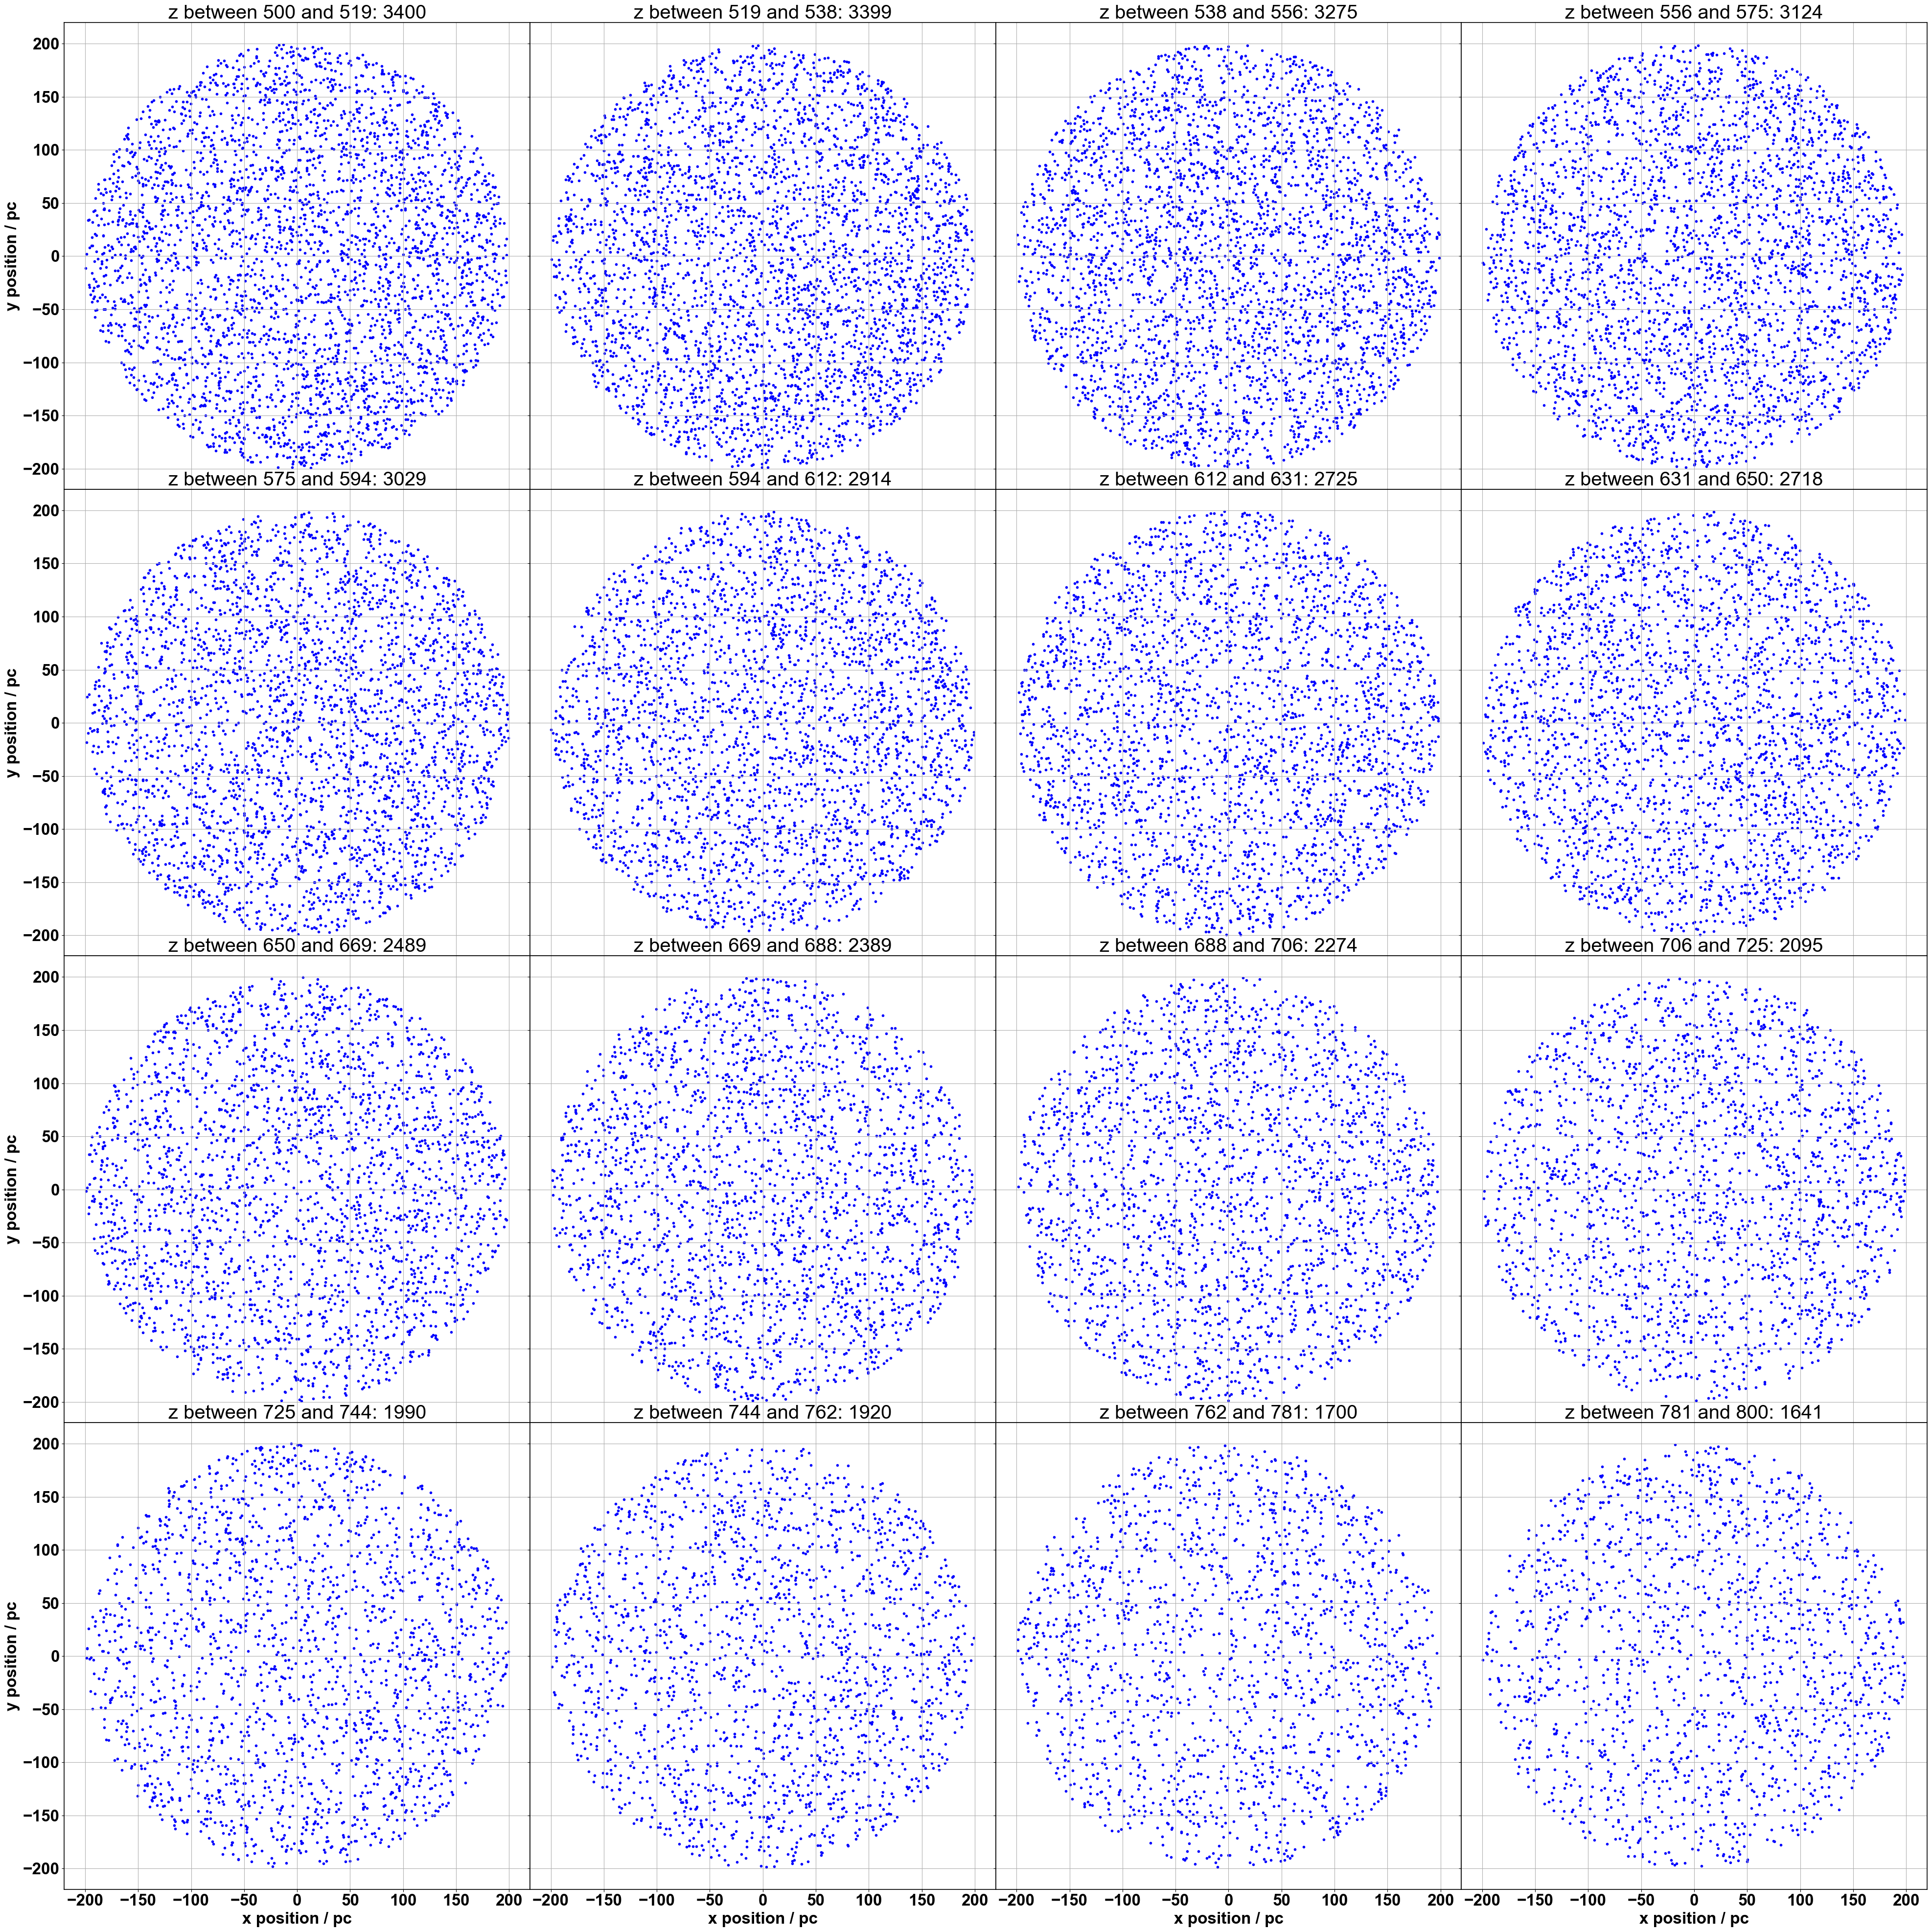

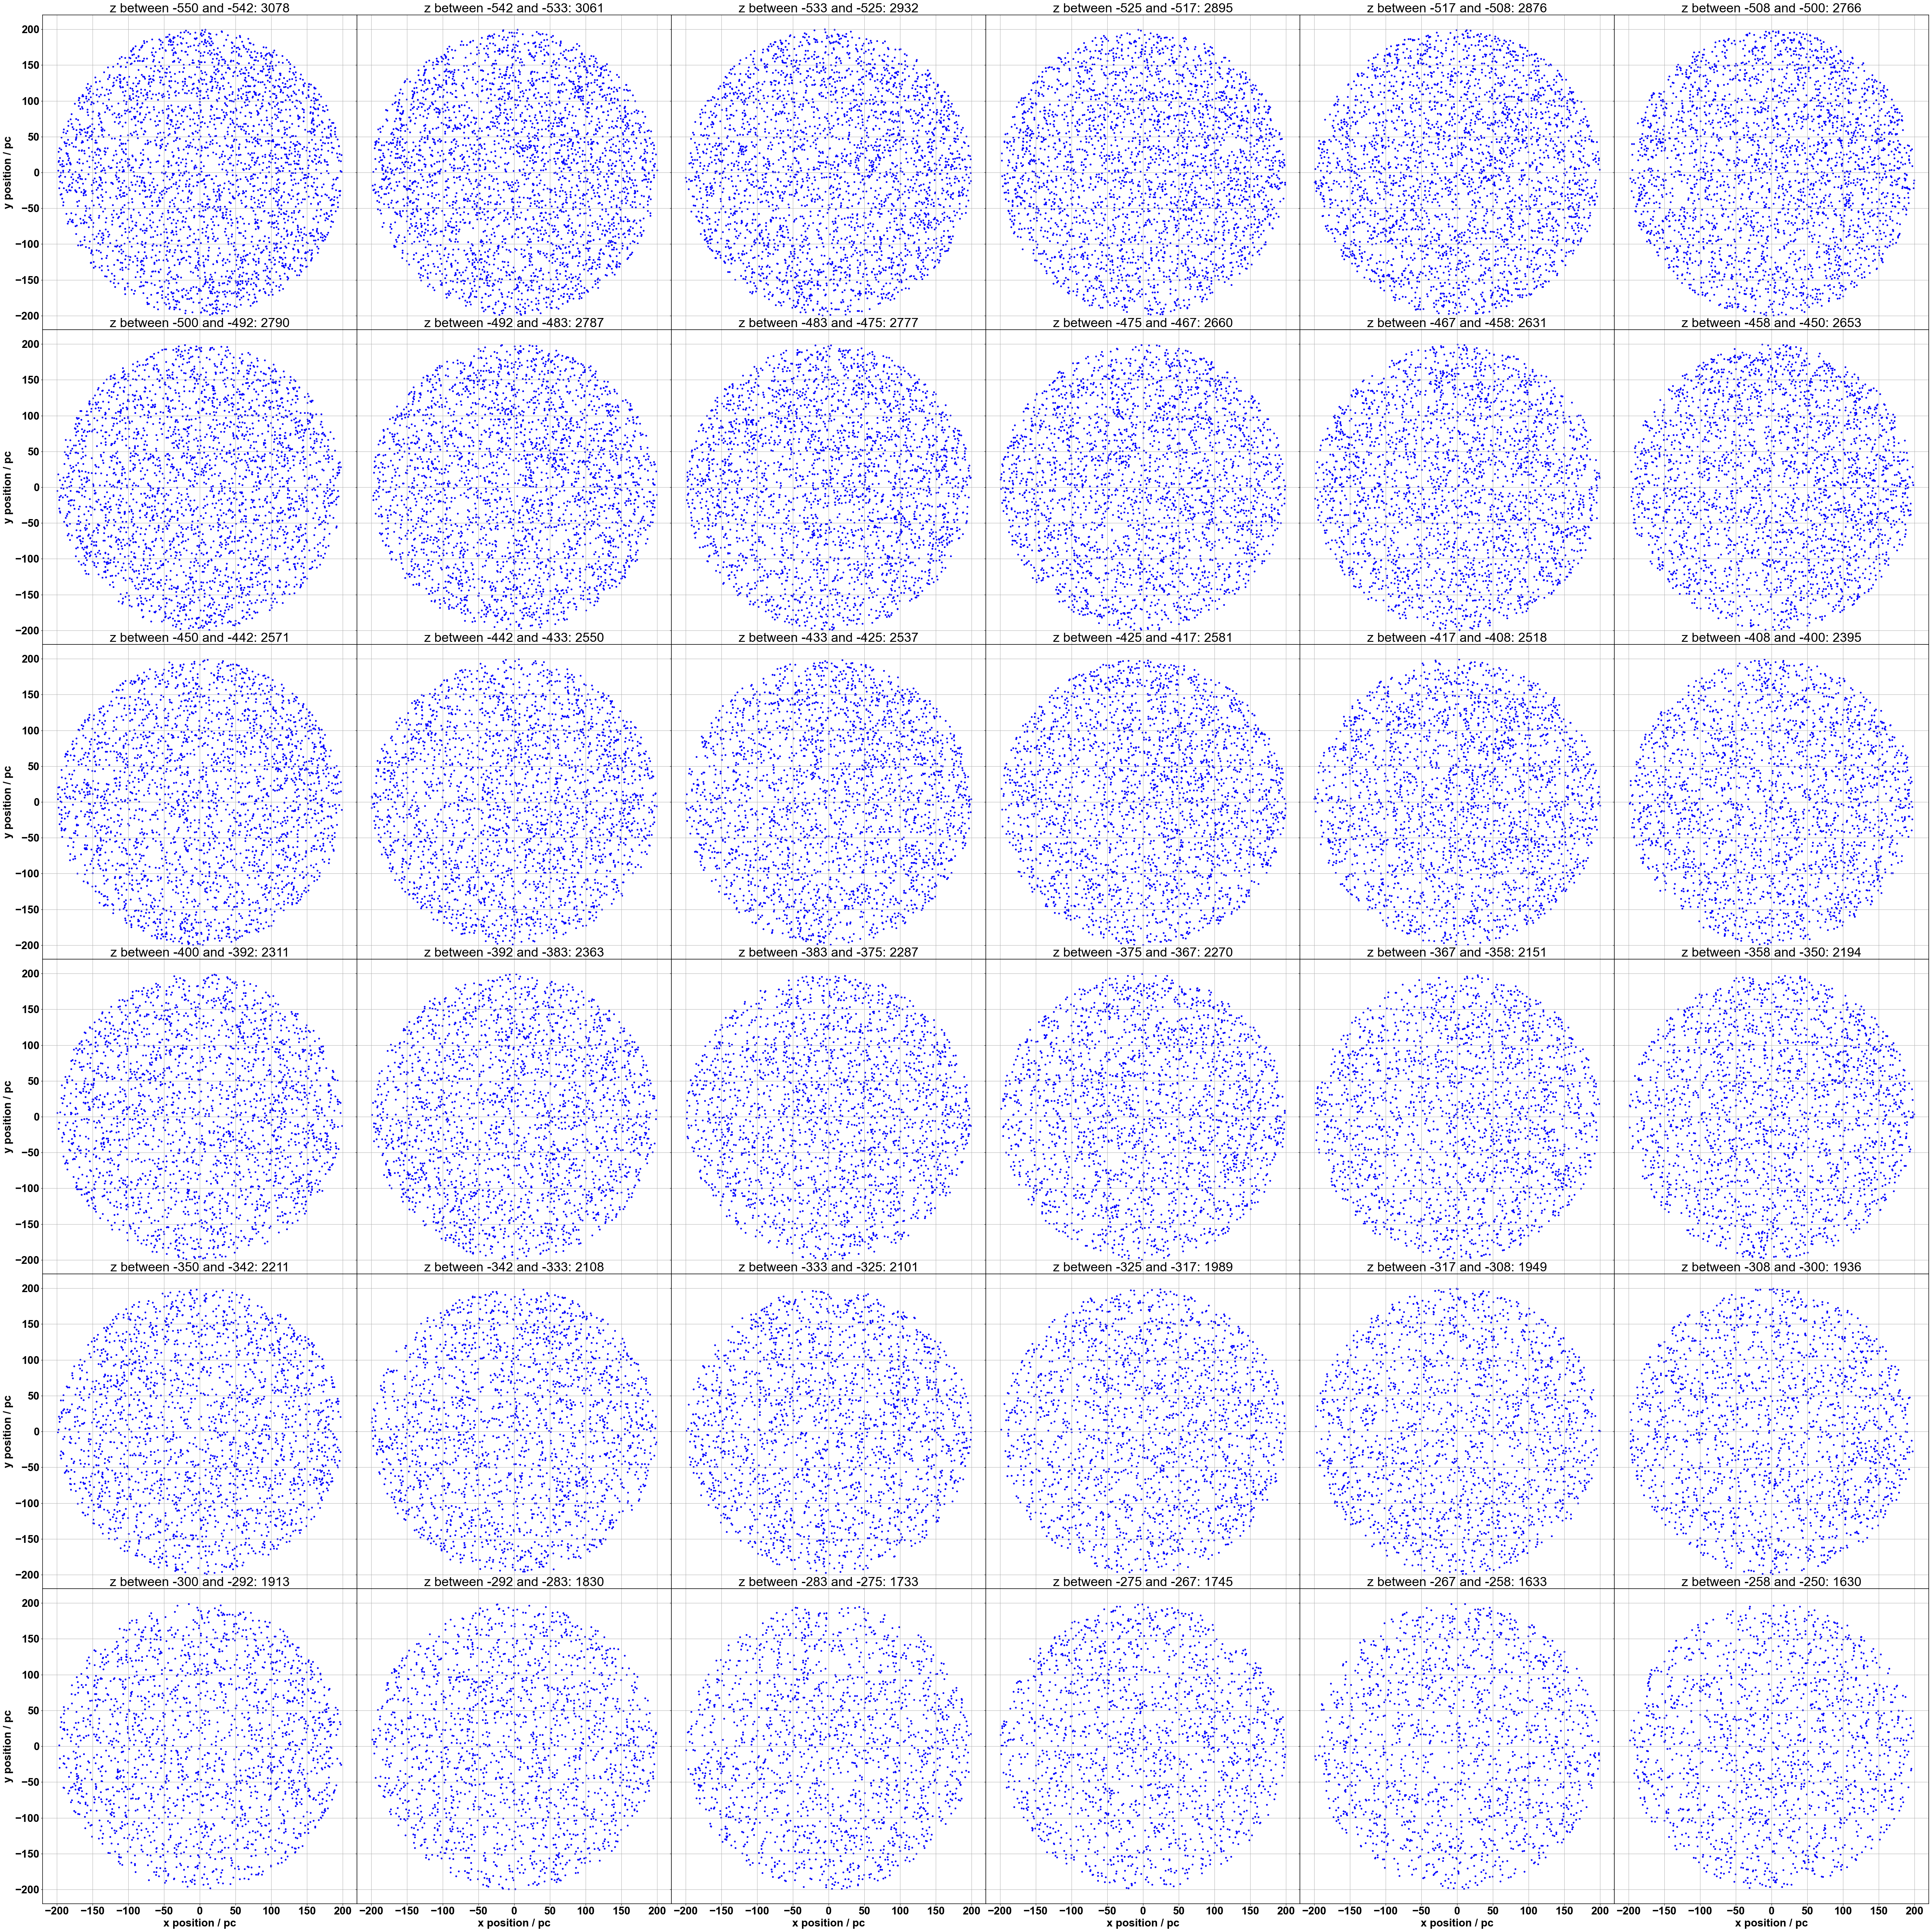

In [8]:
def scan(scan_min, scan_max, n, am_min = 5.0, am_max = 8.0):

    # Absolute magnitude limits
    mask1 = (absolute_magnitude[mask0]>=am_min) & (absolute_magnitude[mask0]<=am_max)
    tab_filtered = tab[mask0][mask1]

    intervals = np.linspace(scan_min, scan_max, n+1)
    length = int(np.ceil(np.sqrt(n)))
    fig, ax = plt.subplots(length, length, figsize=(10*length, 10*length), sharex=True, sharey=True)
    ax = ax.flatten()

    for i in range(n):
        mask = (r_from_plx(tab_filtered["parallax"])*np.sin(tab_filtered["b"]*deg2rad)+14.5 > intervals[i]) & (r_from_plx(tab_filtered["parallax"])*np.sin(tab_filtered["b"]*deg2rad)+14.5  <= intervals[i+1])
        #print(np.nansum(mask))

        data = tab_filtered[mask]

        x = r_from_plx(data["parallax"])*np.cos(data["b"]*deg2rad)*np.cos(data["l"]*deg2rad)
        y = r_from_plx(data["parallax"])*np.cos(data["b"]*deg2rad)*np.sin(data["l"]*deg2rad)

        if scan_min < 0 and scan_max <= 0:
            i = n-i-1
        ax[i].set_title('z between {:.0f} and {:.0f}: {}'.format(intervals[i], intervals[i+1], len(data)))
        ax[i].scatter(x, y, marker='.', color='blue')
        if i % length == 0:
            ax[i].set_ylabel('y position / pc')
        if i >= n-length:
            ax[i].set_xlabel('x position / pc')
        ax[i].grid(True)
    
    fig.tight_layout()
    fig.subplots_adjust(hspace=0., wspace=0.)
    plt.show()

# scan(100, 600, 100)
# scan(-600, -100, 100)
scan(500, 800, 16)
scan(-550, -250, 36)
# scan(100, 120, 9)

